In [1]:
import re
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge import Rouge
from sklearn.feature_extraction.text import CountVectorizer
from transformers import AutoProcessor
from datasets import load_dataset
from transformers import AutoModelForVision2Seq, AutoProcessor
import torch
import json
from PIL import Image

# 1-6

In [4]:
with open("/root/IC_MLLM_VQA/example/1-6example.json", "r", encoding="utf-8") as f:
    dataset_train = json.load(f)

Image path: /root/IC_MLLM_VQA/example/1-6.png


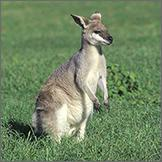

In [ ]:
dataset_train = dataset_train[0]  # Assuming we want the first example for demonstration
image_path = '/root/IC_MLLM_VQA/example/' + dataset_train["image"]
print(f"Image path: {image_path}")
img = Image.open(image_path)
img.show()

# 7-12

In [6]:
with open("/root/IC_MLLM_VQA/example/7-12example.json", "r", encoding="utf-8") as f:
    dataset_train = json.load(f)

Image path: /root/IC_MLLM_VQA/example/7-12.png


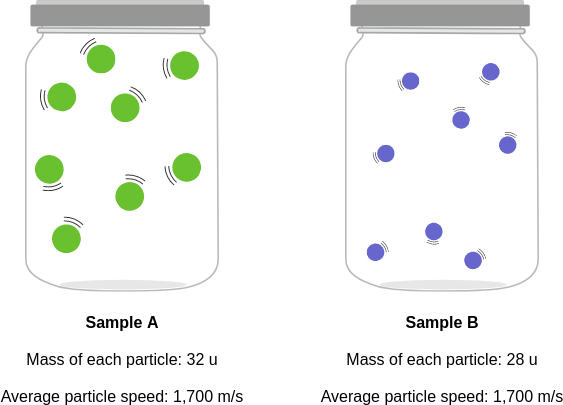

In [7]:
dataset_train = dataset_train[0]
image_path = '/root/IC_MLLM_VQA/example/' + dataset_train["image"]
print(f"Image path: {image_path}")
img = Image.open(image_path)
img.show()

# Arxiv QA

In [2]:
with open("/root/IC_MLLM_VQA/example/ArxivQA.json", "r", encoding="utf-8") as f:
    dataset_train = json.load(f)


Image path: 1805.06771_2.jpg


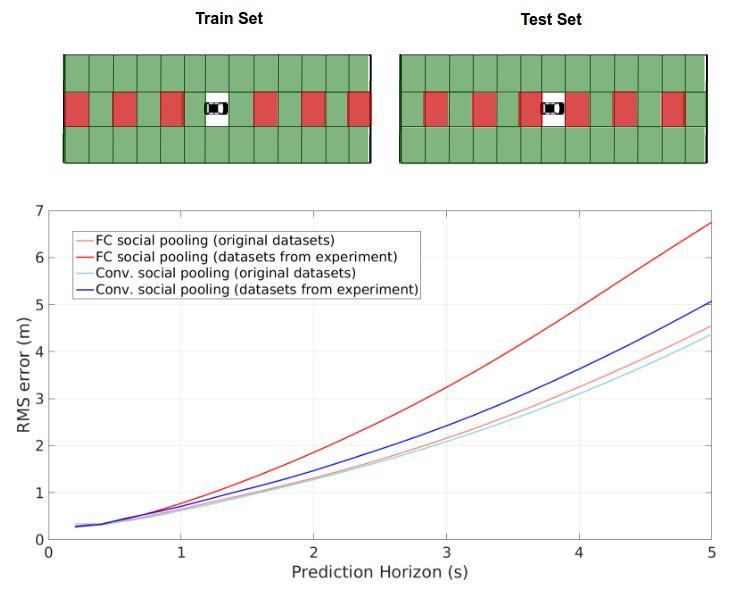

In [3]:
dataset_train = dataset_train[0]

image_path = dataset_train["image"]
print(f"Image path: {image_path}")
img = Image.open(image_path)
img.show()

# setup

In [3]:
import os
import json
import random
from PIL import Image
from datasets import load_dataset

def build_filtered_dataset(dataset_name='derek-thomas/ScienceQA',
                           split='train',
                           keep_grades='7-12'):
    def is_grade_allowed(grade_str):
        if keep_grades is None:
            return True
        try:
            grade_num = int(grade_str.replace("grade", ""))
            if keep_grades == "1-6":
                return 1 <= grade_num <= 6
            elif keep_grades == "7-12":
                return 7 <= grade_num <= 12
        except:
            return False
        return False

    data = load_dataset(dataset_name, split=split)
    dataset = []

    for i, sample in enumerate(data):
        try:
            if sample.get('question') is None:
                continue
            if sample.get("image", None) is None:
                continue
            if not is_grade_allowed(sample.get("grade", "")):
                continue

            solution = sample.get("solution", "")
            lecture = sample.get("lecture", "")
            solution_lecture = f"{solution}\n\n{lecture}".strip()

            image = sample["image"].convert("RGB")

            dataset.append({
                "image": image,
                "question": sample["question"],
                "choices": sample["choices"],
                "hint": sample["hint"],
                "answer": sample["answer"],
                "solution_lecture": solution_lecture,
                "grade": sample["grade"],
            })

        except Exception as e:
            print(f"跳过第 {i} 个样本，错误：{e}")
            continue

    return dataset


def save_random_sample_as_json(dataset, save_dir='./random_sample', json_filename='example_sample.json', image_filename='example_image.png'):
    os.makedirs(save_dir, exist_ok=True)

    sample = random.choice(dataset)

    # 保存图片
    image_path = os.path.join(save_dir, image_filename)
    sample["image"].save(image_path)

    # 构造 json 数据（只保留图片路径）
    json_data = {
        "question": sample["question"],
        "choices": sample["choices"],
        "hint": sample["hint"],
        "grade": sample["grade"],
        "answer": sample["answer"],
        "explanation": sample["solution_lecture"],
        "image": image_filename  # 只保存文件名或相对路径
    }

    # 保存 JSON 文件
    json_path = os.path.join(save_dir, json_filename)
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(json_data, f, indent=4, ensure_ascii=False)

    print(f"✅ 随机样本图像已保存至: {image_path}")
    print(f"✅ 随机样本数据已保存至: {json_path}")


# 执行主流程
dataset_train = build_filtered_dataset(split='train', keep_grades='7-12')
print(f"\n✅ 筛选后的样本数量: {len(dataset_train)}")

# 随机保存一个样本
save_random_sample_as_json(dataset_train)



✅ 筛选后的样本数量: 1869
✅ 随机样本图像已保存至: ./random_sample/example_image.png
✅ 随机样本数据已保存至: ./random_sample/example_sample.json
